In [1]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('../data/processed/mental_health_clean.csv')
print(df.shape)

(11479, 13)


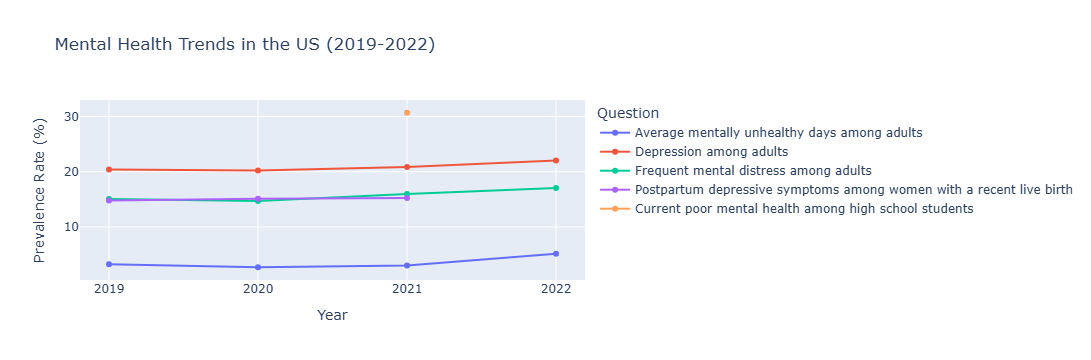

In [7]:
trend_df = df.groupby(['YearStart', 'Question'])['DataValue'].mean().reset_index()
trend_df['YearStart'] = trend_df['YearStart'].astype(str)

fig = px.line(trend_df, x='YearStart', y='DataValue', color='Question',
              title='Mental Health Trends in the US (2019-2022)',
              labels={'DataValue': 'Prevalence Rate (%)', 'YearStart': 'Year'},
              markers=True)  # adds dots on each data point

fig.show()

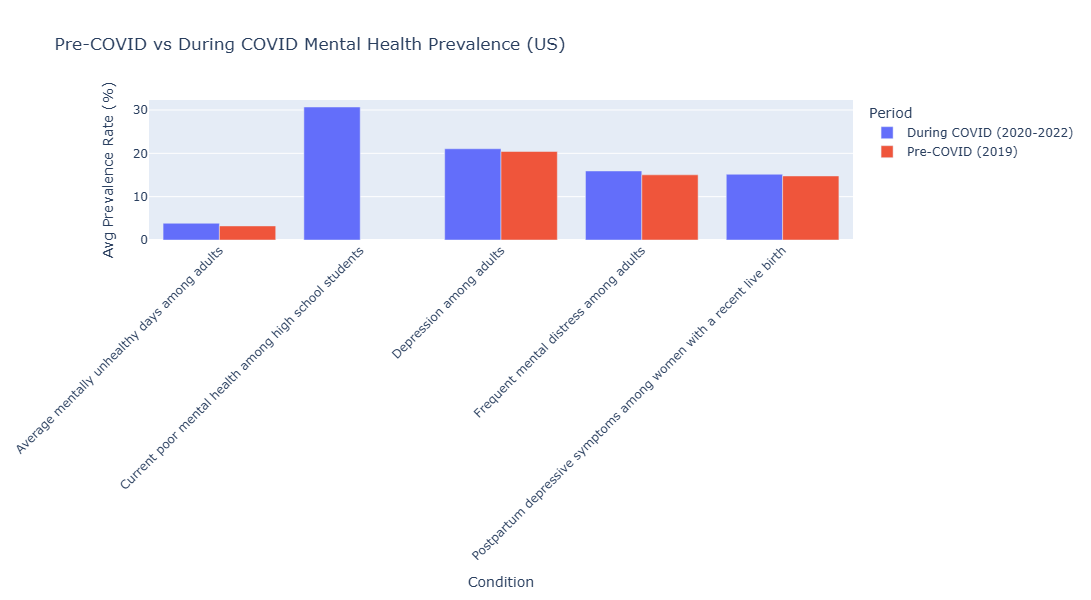

In [5]:
def label_period(year):
    if year <= 2019:
        return 'Pre-COVID (2019)'
    else:
        return 'During COVID (2020-2022)'

df['Period'] = df['YearStart'].apply(label_period)

covid_df = df.groupby(['Period', 'Question'])['DataValue'].mean().reset_index()

fig = px.bar(covid_df, x='Question', y='DataValue', color='Period',
             barmode='group',
             title='Pre-COVID vs During COVID Mental Health Prevalence (US)',
             labels={'DataValue': 'Avg Prevalence Rate (%)', 'Question': 'Condition'})
fig.update_layout(
    xaxis_tickangle=-45,
    height=600,
    margin=dict(b=200)
)
fig.show()
